In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
spotify_df = pd.read_csv("Most Streamed Artists on Spotify (17_07_2026) V1.1.csv")
spotify_df.head()

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


In [3]:
spotify_df.describe()

,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2005.346000,16817.610200,12141.734000,4681.289000,8324.397600,50.613084,8493.212600,49.386916
std,13.312578,14845.197632,11844.675186,5952.827762,9589.010168,33.762147,9612.491536,33.762147
min,1939.000000,6972.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2001.750000,8768.175000,6489.750000,696.500000,2519.775000,20.117951,2015.650000,16.860219
50%,2009.000000,11923.250000,8716.350000,3005.600000,6472.950000,47.062829,6592.250000,52.937171
75%,2014.000000,18020.050000,13456.900000,6093.350000,10115.550000,83.139781,11019.575000,79.882049
max,2023.000000,137492.100000,126177.300000,43710.500000,113421.500000,100.000000,84168.200000,100.000000


In [4]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    object 
 1   Sex                                  500 non-null    object 
 2   Country of Origin                    500 non-null    object 
 3   Primary Language                     500 non-null    object 
 4   Primary Genre                        500 non-null    object 
 5    Artist Type                         500 non-null    object 
 6   Debut Year                           500 non-null    int64  
 7   Total Streams (in millions)          500 non-null    float64
 8   Lead Streams (in millions)           500 non-null    float64
 9   Feature Streams (in millions)        500 non-null    float64
 10  Solo Streams (in millions)           500 non-null    float64
 11  % of Solo Streams               

In [5]:
spotify_df.shape

(500, 14)

In [6]:
spotify_df.isnull().sum()

Artist Name                            0
Sex                                    0
Country of Origin                      0
Primary Language                       0
Primary Genre                          0
 Artist Type                           0
Debut Year                             0
Total Streams (in millions)            0
Lead Streams (in millions)             0
Feature Streams (in millions)          0
Solo Streams (in millions)             0
% of Solo Streams                      0
Collaborative Streams (in millions)    0
% of Collaborative Streams             0
dtype: int64

In [7]:
spotify_df.duplicated().sum()

np.int64(0)

In [8]:
spotify_df.nunique()

Artist Name                            500
Sex                                      3
Country of Origin                       43
Primary Language                        11
Primary Genre                           23
 Artist Type                             2
Debut Year                              61
Total Streams (in millions)            499
Lead Streams (in millions)             498
Feature Streams (in millions)          464
Solo Streams (in millions)             494
% of Solo Streams                      485
Collaborative Streams (in millions)    488
% of Collaborative Streams             485
dtype: int64

In [9]:
spotify_df["Sex"] = spotify_df["Sex"].replace({"Mixed": "Intersex"})

In [10]:
print(spotify_df["Sex"])

0          Male
1        Female
2          Male
3          Male
4          Male
         ...   
495        Male
496    Intersex
497        Male
498        Male
499        Male
Name: Sex, Length: 500, dtype: object


In [11]:
spotify_df = spotify_df.rename(columns={" Artist Type": "Artist Type"})

In [12]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    object 
 1   Sex                                  500 non-null    object 
 2   Country of Origin                    500 non-null    object 
 3   Primary Language                     500 non-null    object 
 4   Primary Genre                        500 non-null    object 
 5   Artist Type                          500 non-null    object 
 6   Debut Year                           500 non-null    int64  
 7   Total Streams (in millions)          500 non-null    float64
 8   Lead Streams (in millions)           500 non-null    float64
 9   Feature Streams (in millions)        500 non-null    float64
 10  Solo Streams (in millions)           500 non-null    float64
 11  % of Solo Streams               

Text(0, 0.5, 'range')

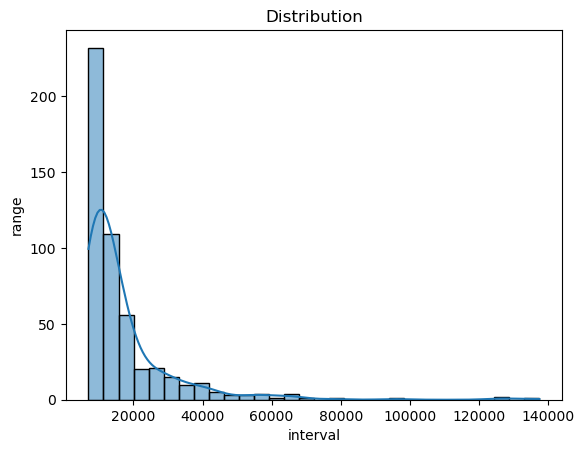

In [13]:
import seaborn as sns
sns.histplot(data=spotify_df, x='Total Streams (in millions)', bins=30, kde=True)
plt.title('Distribution')
plt.xlabel('interval')
plt.ylabel('range')

In [14]:
columns_to_log = ['Total Streams (in millions)',
                    'Lead Streams (in millions)',
                    'Feature Streams (in millions)',
                    'Solo Streams (in millions)',	
                    '% of Solo Streams',
                    'Collaborative Streams (in millions)',	
                    '% of Collaborative Streams']


spotify_df[columns_to_log] = np.log1p(spotify_df[columns_to_log])
spotify_df.head()

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,11.831329,11.460074,10.660593,10.884159,3.683446,11.340584,4.130624
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,11.758707,11.745451,7.429402,11.638875,4.496547,9.577792,2.509040
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,11.743250,11.316793,10.685367,10.797287,3.684623,11.251740,4.129871
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,11.469017,11.254030,9.826326,10.839993,3.994720,10.707375,3.864708
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,11.265814,10.785543,10.301901,10.296856,3.662203,10.788640,4.143975


In [15]:
spotify_df.describe()

,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2005.346000,9.527462,9.056352,7.089816,8.252127,3.513295,8.071055,3.410342
std,13.312578,0.567558,1.089261,2.605488,1.832751,1.192348,2.133389,1.325438
min,1939.000000,8.849801,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2001.750000,9.078995,8.778133,6.547483,7.832310,3.050100,7.609178,2.882570
50%,2009.000000,9.386323,9.073067,8.008564,8.775525,3.872509,8.793800,3.987820
75%,2014.000000,9.799295,9.507308,8.715117,9.221927,4.432479,9.307519,4.392990
max,2023.000000,11.831329,11.745451,10.685367,11.638875,4.615121,11.340584,4.615121


Text(0, 0.5, 'Count of Songs')

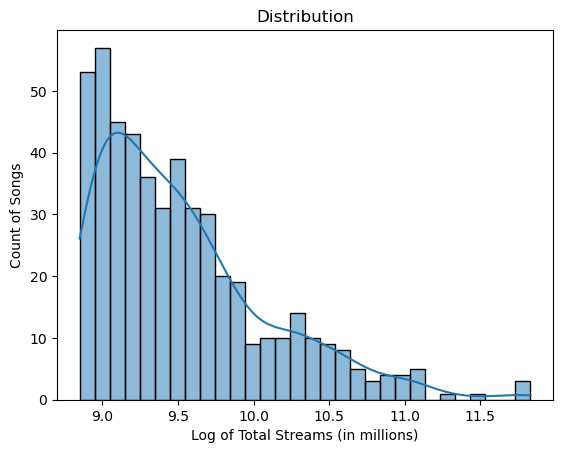

In [16]:
sns.histplot(data=spotify_df, x='Total Streams (in millions)', bins=30, kde=True)
plt.title('Distribution')
plt.xlabel('Log of Total Streams (in millions)')
plt.ylabel('Count of Songs')

In [17]:
spotify_df[[ "Total Streams (in millions)",
        "Lead Streams (in millions)",
        "Feature Streams (in millions)",
        "Solo Streams (in millions)",
        "Collaborative Streams (in millions)"
           ]].corr()

,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),Collaborative Streams (in millions)
Total Streams (in millions),1.000000,0.562037,0.301650,0.365180,0.356618
Lead Streams (in millions),0.562037,1.000000,-0.135358,0.617303,0.004486
Feature Streams (in millions),0.301650,-0.135358,1.000000,-0.204409,0.735455
Solo Streams (in millions),0.365180,0.617303,-0.204409,1.000000,-0.275086
Collaborative Streams (in millions),0.356618,0.004486,0.735455,-0.275086,1.000000


In [18]:
spotify_df[ "Lead Streams (in millions)"] + spotify_df[ "Feature Streams (in millions)"]

0      22.120667
1      19.174853
2      22.002159
3      21.080356
4      21.087444
         ...    
495    10.317410
496    15.802133
497    10.712731
498    16.277509
499    11.906211
Length: 500, dtype: float64

In [19]:
spotify_df[[ "Total Streams (in millions)",
        "% of Solo Streams",
        "% of Collaborative Streams"
           ]].corr()

,Total Streams (in millions),% of Solo Streams,% of Collaborative Streams
Total Streams (in millions),1.000000,0.037224,0.118270
% of Solo Streams,0.037224,1.000000,-0.661202
% of Collaborative Streams,0.118270,-0.661202,1.000000


In [20]:
spotify_df[["Total Streams (in millions)",
        "Solo Streams (in millions)",
        "% of Solo Streams",
        "Collaborative Streams (in millions)",
        "% of Collaborative Streams"
           ]].head(10)

,Total Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,11.831329,10.884159,3.683446,11.340584,4.130624
1,11.758707,11.638875,4.496547,9.577792,2.509040
2,11.743250,10.797287,3.684623,11.251740,4.129871
3,11.469017,10.839993,3.994720,10.707375,3.864708
4,11.265814,10.296856,3.662203,10.788640,4.143975
5,11.131664,10.636252,4.126028,10.191834,3.690592
6,11.087523,10.138990,3.682105,10.597654,4.131481
7,11.084354,10.256747,3.800164,10.509739,4.048152
8,11.076866,10.751521,4.293570,9.795785,3.359423
9,11.075195,10.402473,3.951840,10.361229,3.911403


In [21]:
threshold = spotify_df['Total Streams (in millions)'].quantile(0.8)
spotify_df['High Stream Artist'] = (spotify_df['Total Streams (in millions)'] >= threshold).astype(int)


In [22]:
print("threshold:", threshold)
print(spotify_df['High Stream Artist'].value_counts())

threshold: 9.919872520172087
High Stream Artist
0    400
1    100
Name: count, dtype: int64


In [23]:
features = ['Sex',
    'Country of Origin',
    'Primary Language',
    'Primary Genre',
    'Artist Type',
    'Debut Year'
           ]

X = spotify_df[features]
y = spotify_df['High Stream Artist']

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42,
                                                    stratify = y
                                                   )

In [25]:
print(X_train.shape)
print(y_train.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(400, 6)
(400,)
High Stream Artist
0    320
1     80
Name: count, dtype: int64
High Stream Artist
0    80
1    20
Name: count, dtype: int64


In [40]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'Sex',
    'Country of Origin',
    'Primary Language',
    'Primary Genre',
    'Artist Type'
]

encoder = OneHotEncoder(
    drop='first',
    min_frequency = 5,
    handle_unknown='infrequent_if_exist',
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_encoded = encoder.transform(
    X_test[categorical_features]
)

C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [41]:
encoder.categories_

[array(['Female', 'Intersex', 'Male'], dtype=object),
 array(['Argentina', 'Australia', 'Barbados', 'Belgium', 'Brazil',
        'Canada', 'Chile', 'Colombia', 'Cuba', 'DR Congo', 'Denmark',
        'Dominican Republic', 'France', 'Germany', 'Guatemala', 'Iceland',
        'India', 'Ireland', 'Italy', 'Jamaica', 'Japan', 'Mexico',
        'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'Norway',
        'Panama', 'Philippines', 'Russia', 'Scotland', 'South Africa',
        'South Korea', 'Spain', 'Sweden', 'Trinidad and Tobago',
        'United Kingdom', 'United States', 'Venezuela'], dtype=object),
 array(['English', 'French', 'German', 'Hindi', 'Italian', 'Korean',
        'Portuguese', 'Punjabi', 'Spanish', 'Tamil'], dtype=object),
 array(['Afrobeats', 'Alternative', 'Bachata', 'Country', 'EDM', 'Filmi',
        'Folk', 'Hip-Hop', 'K-Pop', 'Latin', 'Metal', 'Pop', 'R&B',
        'Reggae', 'Reggaeton', 'Regional Mexican', 'Rock', 'Sertanjeo',
        'Soul', 'Soundtrack', 'Spoken

In [42]:
encoder.get_feature_names_out()

array(['Sex_Intersex', 'Sex_Male', 'Country of Origin_Australia',
       'Country of Origin_Brazil', 'Country of Origin_Canada',
       'Country of Origin_Colombia', 'Country of Origin_Germany',
       'Country of Origin_India', 'Country of Origin_Mexico',
       'Country of Origin_South Korea', 'Country of Origin_Spain',
       'Country of Origin_United Kingdom',
       'Country of Origin_United States',
       'Country of Origin_infrequent_sklearn', 'Primary Language_German',
       'Primary Language_Hindi', 'Primary Language_Korean',
       'Primary Language_Portuguese', 'Primary Language_Spanish',
       'Primary Language_infrequent_sklearn', 'Primary Genre_Country',
       'Primary Genre_EDM', 'Primary Genre_Filmi',
       'Primary Genre_Hip-Hop', 'Primary Genre_K-Pop',
       'Primary Genre_Latin', 'Primary Genre_Metal', 'Primary Genre_Pop',
       'Primary Genre_R&B', 'Primary Genre_Reggaeton',
       'Primary Genre_Regional Mexican', 'Primary Genre_Rock',
       'Primary Genre_

In [43]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(400, 35)
(100, 35)


In [46]:
encoder.get_feature_names_out()

array(['Sex_Intersex', 'Sex_Male', 'Country of Origin_Australia',
       'Country of Origin_Brazil', 'Country of Origin_Canada',
       'Country of Origin_Colombia', 'Country of Origin_Germany',
       'Country of Origin_India', 'Country of Origin_Mexico',
       'Country of Origin_South Korea', 'Country of Origin_Spain',
       'Country of Origin_United Kingdom',
       'Country of Origin_United States',
       'Country of Origin_infrequent_sklearn', 'Primary Language_German',
       'Primary Language_Hindi', 'Primary Language_Korean',
       'Primary Language_Portuguese', 'Primary Language_Spanish',
       'Primary Language_infrequent_sklearn', 'Primary Genre_Country',
       'Primary Genre_EDM', 'Primary Genre_Filmi',
       'Primary Genre_Hip-Hop', 'Primary Genre_K-Pop',
       'Primary Genre_Latin', 'Primary Genre_Metal', 'Primary Genre_Pop',
       'Primary Genre_R&B', 'Primary Genre_Reggaeton',
       'Primary Genre_Regional Mexican', 'Primary Genre_Rock',
       'Primary Genre_

In [49]:
X_train_final = np.column_stack([X_train_encoded,
                                 X_train['Debut Year']
                                ])

X_test_final = np.column_stack([X_test_encoded,
                                X_test['Debut Year']
                               ])

In [51]:
print(X_train_final.shape)
print(X_test_final.shape)

(400, 36)
(100, 36)


In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


model = LogisticRegression(
    class_weight = 'balanced',
    max_iter = 1000,
    random_state = 42)

model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.51      0.64        80
           1       0.25      0.65      0.36        20

    accuracy                           0.54       100
   macro avg       0.55      0.58      0.50       100
weighted avg       0.73      0.54      0.58       100



In [55]:
print(y_train.shape)
print(y_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(400,)
(100,)
High Stream Artist
0    320
1     80
Name: count, dtype: int64
High Stream Artist
0    80
1    20
Name: count, dtype: int64


In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[41 39]
 [ 7 13]]


In [69]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_final, y_train)

y_pred_rf = rf_model.predict(X_test_final)

print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

              precision    recall  f1-score   support

           0       0.83      0.86      0.85        80
           1       0.35      0.30      0.32        20

    accuracy                           0.75       100
   macro avg       0.59      0.58      0.59       100
weighted avg       0.74      0.75      0.74       100

[[69 11]
 [14  6]]
